## PREPARATION

In [1]:
import pandas as pd

In [2]:
import seaborn as sns

In [3]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("esg_raw.csv")

In [5]:
pd.set_option('display.max_columns', None)  # afficher toutes les colonnes
pd.set_option('display.max_rows', None)     # afficher toutes les lignes

# OBJECTIFS EDA
- comprendre la structure du dataset
- cartographier les problèmes de qualité
- préparer les décisions de nettoyage dans Dataiku

## 1. Vue d'ensmble du dataset

In [6]:
df.shape

(20000, 36)

In [7]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Company_ID                   20000 non-null  object 
 1   Company_Name                 20000 non-null  object 
 2   Sector                       20000 non-null  object 
 3   Country                      20000 non-null  object 
 4   Fiscal_Year                  20000 non-null  int64  
 5   Employees                    20000 non-null  int64  
 6   CO2_Scope1                   20000 non-null  float64
 7   CO2_Scope2                   18000 non-null  float64
 8   CO2_Scope3                   20000 non-null  float64
 9   Energy_Consumption_MWh       20000 non-null  object 
 10  Renewable_Energy_Ratio       20000 non-null  float64
 11  Water_Consumption_m3         20000 non-null  float64
 12  Waste_Recycled_Ratio         20000 non-null  float64
 13  Hazardous_Waste_

In [8]:
for col in df.columns:
    print(col, df[col].dtype, df[col].notnull().sum())

Company_ID object 20000
Company_Name object 20000
Sector object 20000
Country object 20000
Fiscal_Year int64 20000
Employees int64 20000
CO2_Scope1 float64 20000
CO2_Scope2 float64 18000
CO2_Scope3 float64 20000
Energy_Consumption_MWh object 20000
Renewable_Energy_Ratio float64 20000
Water_Consumption_m3 float64 20000
Waste_Recycled_Ratio float64 20000
Hazardous_Waste_Tons float64 20000
Climate_Risk_Exposure int64 20000
Gender_Equality_Ratio float64 18000
Employee_Turnover float64 20000
Work_Accidents object 20000
LTI_Frequency float64 20000
Training_Hours_per_Employee float64 18000
Diversity_Index int64 20000
Social_Incidents int64 20000
Board_Independence_Ratio object 20000
Anti_Corruption_Score int64 20000
Supplier_ESG_Score int64 20000
Data_Privacy_Incidents int64 20000
Whistleblower_Cases int64 20000
Ethical_Score int64 20000
Materiality_Impact int64 20000
Materiality_Financial int64 20000
Risk_Classification object 20000
Risk_Description object 20000
Controversy_Level object 1498

## Types suspects colonnes :
- Energy_Consumption_MWh = object
- Board_Independence_Ratio = object
- Revenue = object

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company_ID,20000,4000,C_0001,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company_Name,20000,4000,Company_0001,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sector,20000,5,Industry,4145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,20000,7,Netherlands,3060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fiscal_Year,20000.0,NaN,NaN,NaN,2022.0,1.414249,2020.0,2021.0,2022.0,2023.0,2024.0
Employees,20000.0,NaN,NaN,NaN,5023.3709,2884.192975,50.0,2510.0,5034.5,7523.0,9999.0
CO2_Scope1,20000.0,NaN,NaN,NaN,489.192535,141.845231,-50.0,413.0,497.0,579.5,972.6
CO2_Scope2,18000.0,NaN,NaN,NaN,299.408017,79.813395,6.0,246.2,300.1,352.9,594.5
CO2_Scope3,20000.0,NaN,NaN,NaN,1997.976485,499.995537,-50.1,1659.7,1996.3,2340.5,3892.4
Energy_Consumption_MWh,20000,18428,13021.4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Analyse de la qualité des données

- 2.1 Valeurs manquantes

In [10]:
# affiche le pourcentage de valeurs manquantes par colonnes

df.isna().mean().sort_values(ascending=False)*100

Controversy_Level              25.100
Currency                       20.315
Gender_Equality_Ratio          10.000
CO2_Scope2                     10.000
Training_Hours_per_Employee    10.000
Whistleblower_Cases             0.000
Social_Incidents                0.000
Board_Independence_Ratio        0.000
Anti_Corruption_Score           0.000
Supplier_ESG_Score              0.000
Data_Privacy_Incidents          0.000
Materiality_Impact              0.000
Ethical_Score                   0.000
Materiality_Financial           0.000
Risk_Classification             0.000
Risk_Description                0.000
Certifications                  0.000
Revenue                         0.000
Diversity_Index                 0.000
Company_ID                      0.000
Company_Name                    0.000
Work_Accidents                  0.000
Employee_Turnover               0.000
Climate_Risk_Exposure           0.000
Hazardous_Waste_Tons            0.000
Waste_Recycled_Ratio            0.000
Water_Consum

- quelles seront les imputations ? globale ? sectorielle ? par année ?
- comment : mediane/ moyenne ?
- quelles données resteront vides ?

- 2.2 Types et formats incohérents
- unique()[:x] permet d'avoir un aperçu des des données
- à approfondir avec .sample(x) si besoin ou value_counts()

In [11]:
df["Energy_Consumption_MWh"].unique()[:20]

array(['16067.9', '16288.4', '11087.6', '15594.8', '9006.7', '20477.6',
       '14195.8', '16396.6', '15917.5', '19153.4', '14719.9', '11730.5',
       '16202.4', '19044.2', '18570.1', '12272.4', '13063.8', '15540.2',
       '17311.1', '9700.5'], dtype=object)

In [ ]:
# df["Energy_Consumption_MWh"].value_counts().sort_values(ascending=False)

Energy_Consumption_MWh
13021.4     5
14809.1     5
16074.9     4
17726.4     4
15697.9     4
15764.5     4
14755.8     4
14186.4     4
14703.8     3
11204.1     3
14640.4     3
17231.9     3
12290.7     3
14214.3     3
14077.0     3
15536.9     3
16509.8     3
16187.4     3
15020.7     3
15941.5     3
16704.2     3
16717.8     3
17274.7     3
15023.8     3
13894.3     3
15246.7     3
13950.4     3
14597.8     3
14308.9     3
13976.7     3
15961.2     3
15858.3     3
13825.1     3
13167.4     3
13817.0     3
17491.6     3
15184.1     3
13343.5     3
15564.4     3
12799.8     3
15969.1     3
14404.1     3
16837.3     3
14047.6     3
16344.8     3
16232.3     3
12384.6     3
14806.1     3
16087.3     3
14382.4     3
18856.8     3
16422.1     3
12954.9     3
12990.3     3
14462.2     3
13469.5     3
13900.1     3
19141.7     3
16951.7     3
17214.4     3
14778.7     3
14228.0     3
16130.6     3
12800.6     3
14090.6     3
16572.1     3
14587.3     3
14959.0     3
14727.7     3
14972.7    

In [13]:
df["Revenue"].unique()[:20]

array(['406949999', '313289869', '268766350', '247563313', '80141185',
       '237482668', '139593077', '181.09M', '58399217', '201.64M',
       '227962348', '259858948', '233543965', '435660406', '60394100',
       '329800885', '480353980', '315414258', '135.26M', '140636090'],
      dtype=object)

In [ ]:
# df["Revenue"].value_counts()

Revenue
174.09M      3
491.26M      2
63.49M       2
378.87M      2
45.40M       2
218.09M      2
406.16M      2
228.84M      2
97.46M       2
142.85M      2
287.19M      2
15.87M       2
469.62M      2
417.54M      2
36.19M       2
155.38M      2
114.99M      2
62.36M       2
90.85M       2
454.13M      2
471.23M      2
269.90M      2
375.10M      2
141.93M      2
26.46M       2
309.73M      2
158.62M      2
277.77M      2
13.36M       2
223.14M      2
126.61M      2
187.87M      2
400.86M      2
259.50M      2
34.27M       2
322.37M      2
375.38M      2
499.34M      2
108.13M      2
89.44M       2
446.19M      2
408.16M      2
125.79M      2
404.73M      2
278.72M      2
181.81M      2
169.35M      2
113.46M      2
134.86M      2
490.55M      2
347.74M      2
301.60M      2
96.59M       2
283.70M      2
38.12M       2
442.20M      2
417.56M      2
218.05M      2
64.83M       2
381.16M      2
121.22M      2
19.56M       2
475.61M      2
76.92M       2
193.18M      2
108.02M      2
41

In [15]:
df["Board_Independence_Ratio"].unique()[:20]

array(['0.66', '0.78', '0.54', '0.24', '0.72', '0.31', '0.29', '0.22',
       '0.52', '0.36', '0.63', '50%', '0.67', '0.42', '0.82', '0.84',
       '0.6', '0.34', '0.51', '0.85'], dtype=object)

In [ ]:
# df["Board_Independence_Ratio"].value_counts()

Board_Independence_Ratio
0.34    298
0.82    298
0.67    297
0.63    296
0.49    295
0.55    293
0.59    292
0.51    292
0.43    291
0.71    291
0.23    290
0.58    289
0.36    289
0.4     288
0.29    287
0.6     286
0.84    285
0.47    284
0.5     284
0.57    284
0.79    281
0.24    281
0.44    281
0.85    280
0.72    280
0.69    279
0.28    278
0.39    278
0.38    278
0.52    277
0.21    276
0.8     274
0.35    273
0.3     272
0.78    272
0.41    271
0.62    271
0.68    270
0.37    268
0.66    268
0.87    268
0.31    267
0.89    267
0.56    266
0.53    266
0.86    265
0.7     265
0.46    264
0.81    263
0.74    262
0.22    261
0.32    261
0.77    261
0.25    259
0.42    258
0.54    258
0.33    257
0.61    256
0.76    254
0.27    253
0.75    251
0.83    251
0.73    250
0.64    247
0.45    247
0.88    246
0.26    242
0.65    237
0.48    231
0.2     129
0.9     121
81%      22
73%      20
68%      20
78%      19
69%      19
82%      18
43%      18
49%      18
58%      18
30%      18
61%

In [17]:
df["Work_Accidents"].unique()[:20]

array(['3', '6', 'none', '4', '1', '5', '2', '0', '7', '2 accidents', '8',
       '10', '9', '11'], dtype=object)

In [18]:
df["Work_Accidents"].value_counts()

Work_Accidents
3              4326
2              4297
4              3064
1              2754
5              1912
6               930
0               929
2 accidents     600
none            589
7               381
8               153
9                43
10               17
11                5
Name: count, dtype: int64

In [19]:
df["Currency"].unique()[:20]

array([nan, 'EURO', 'usd', 'USD', 'EUR'], dtype=object)

In [20]:
df["Risk_Classification"].unique()[:20]

array(['High', 'Low', 'Medium', 'L', 'M', 'H'], dtype=object)

In [21]:
df["Certifications"].unique()[:20]

array(["{'ISO14001': True, 'ISO45001': False}",
       "{'ISO14001': False, 'ISO45001': True}",
       "{'ISO14001': False, 'ISO45001': False}",
       "{'ISO14001': True, 'ISO45001': True}"], dtype=object)

TO DO:
- "Energy_Consumption_Mwh" : valeurs numériques + "10,5k" => à parser en Mwh
- "Work_Accidents" : entiers + "none", "2 accidents" => à parser en int
- "Board_Independence_Ratio" : nombre + ratio => à ramener [0:1]
- "Revenue" : entiers + "12.54M" → conversion en valeur numérique unique
- "Currency" : "EUR", "EURO", "usd", "" → mapping vers ["EUR","USD"] + NaN
- "Risk_Classification" : "High","Medium","Low","H","M","L" → mapping vers 3 catégories standard
- "Certifications" : pseudo JSON → extraction à prévoir (ISO14001, ISO45001)

- 2.3 Valeurs impossibles/ aberrantes

In [22]:
# afficher le min et le max des colonnes
# pour vérifier la présence de valeurs aberrantes/ impossibles

df[["Renewable_Energy_Ratio", "Waste_Recycled_Ratio", "CO2_Scope1"]].describe()

,Renewable_Energy_Ratio,Waste_Recycled_Ratio,CO2_Scope1
count,20000.000000,20000.000000,20000.000000
mean,0.368851,0.466904,489.192535
std,0.209382,0.231611,141.845231
min,-0.200000,-0.100000,-50.000000
25%,0.248827,0.317509,413.000000
50%,0.351288,0.452128,497.000000
75%,0.456435,0.593526,579.500000
max,1.400000,1.300000,972.600000


In [23]:
# pour afficher les lignes uniquement avec des valeurs aberrantes

df[df["Renewable_Energy_Ratio"] < 0]

,Company_ID,Company_Name,Sector,Country,Fiscal_Year,Employees,CO2_Scope1,CO2_Scope2,CO2_Scope3,Energy_Consumption_MWh,Renewable_Energy_Ratio,Water_Consumption_m3,Waste_Recycled_Ratio,Hazardous_Waste_Tons,Climate_Risk_Exposure,Gender_Equality_Ratio,Employee_Turnover,Work_Accidents,LTI_Frequency,Training_Hours_per_Employee,Diversity_Index,Social_Incidents,Board_Independence_Ratio,Anti_Corruption_Score,Supplier_ESG_Score,Data_Privacy_Incidents,Whistleblower_Cases,Ethical_Score,Materiality_Impact,Materiality_Financial,Risk_Classification,Risk_Description,Controversy_Level,Certifications,Revenue,Currency
94,C_0019,Company_0019,Industry,Germany,2024,5260,343.2,NaN,1274.3,15764.5,-0.100921,11331.0,0.722352,66.6,59,NaN,0.31,4,0.40,32.8,24,0,0.23,49,69,1,0,24,90,72,Medium,Risk details for ESG exposure...,Medium,"{'ISO14001': False, 'ISO45001': False}",271.61M,usd
131,C_0027,Company_0027,Retail,USA,2021,3435,641.9,289.9,1553.4,15887.2,-0.023326,9501.1,0.504547,51.0,10,0.40,0.15,3,3.07,14.4,89,0,0.9,72,89,1,0,96,92,7,H,Risk details for ESG exposure...,Low,"{'ISO14001': False, 'ISO45001': False}",205383047,EUR
144,C_0029,Company_0029,Tech,UK,2024,273,490.1,NaN,1390.0,12885.8,-0.071460,9851.8,0.381759,77.0,54,0.59,0.22,6,3.61,8.2,75,2,0.84,49,80,0,1,80,62,87,L,Risk details for ESG exposure...,High,"{'ISO14001': True, 'ISO45001': True}",281536004,NaN
336,C_0068,Company_0068,Finance,Netherlands,2021,1802,566.2,NaN,2227.2,14667.6,-0.097447,9448.3,0.320181,48.8,35,0.56,0.39,4,0.01,38.6,49,0,0.56,96,83,1,1,23,85,15,Low,Risk details for ESG exposure...,High,"{'ISO14001': False, 'ISO45001': True}",353434525,NaN
349,C_0070,Company_0070,Tech,UK,2024,7898,531.1,320.1,3095.3,14627.4,-0.010690,4408.2,0.045189,20.2,93,0.45,0.35,1,1.59,5.1,86,0,0.2,51,43,0,1,31,88,21,L,Risk details for ESG exposure...,Low,"{'ISO14001': True, 'ISO45001': False}",268690519,usd
360,C_0073,Company_0073,Energy,Germany,2020,1670,320.5,267.0,1701.3,21149.9,-0.034498,8014.3,0.385371,36.8,94,0.56,0.08,4,2.69,55.1,79,0,0.2,47,99,0,1,80,51,4,High,Risk details for ESG exposure...,Medium,"{'ISO14001': False, 'ISO45001': False}",66146259,USD
416,C_0084,Company_0084,Energy,France,2021,9694,675.6,292.5,1129.9,15294.0,-0.045370,7155.8,0.632827,28.1,78,0.48,0.20,0,4.58,26.2,21,4,0.23,38,91,1,0,87,37,41,High,Risk details for ESG exposure...,Low,"{'ISO14001': True, 'ISO45001': True}",438795498,USD
451,C_0091,Company_0091,Retail,UK,2021,7975,554.6,223.5,1540.7,16986.5,-0.028636,9549.0,0.775692,20.1,19,0.35,0.33,3,2.80,49.3,77,1,0.55,80,71,0,0,82,77,89,H,Risk details for ESG exposure...,High,"{'ISO14001': True, 'ISO45001': False}",432014660,usd
751,C_0151,Company_0151,Industry,Italy,2021,7910,508.0,225.3,1791.4,15609.0,-0.036833,7079.8,0.652622,52.4,66,0.48,0.29,0,0.59,13.2,47,1,0.61,76,71,0,0,96,73,32,M,Risk details for ESG exposure...,High,"{'ISO14001': False, 'ISO45001': True}",227792974,USD
789,C_0158,Company_0158,Energy,Netherlands,2024,9331,464.5,258.3,1817.2,6628.9,-0.116801,9533.4,0.483858,65.5,10,0.59,0.23,1,2.23,33.8,36,1,0.33,55,83,0,0,49,26,35,Medium,Risk details for ESG exposure...,Medium,"{'ISO14001': False, 'ISO45001': False}",262405575,NaN


In [24]:
df[df["Renewable_Energy_Ratio"] > 1]

,Company_ID,Company_Name,Sector,Country,Fiscal_Year,Employees,CO2_Scope1,CO2_Scope2,CO2_Scope3,Energy_Consumption_MWh,Renewable_Energy_Ratio,Water_Consumption_m3,Waste_Recycled_Ratio,Hazardous_Waste_Tons,Climate_Risk_Exposure,Gender_Equality_Ratio,Employee_Turnover,Work_Accidents,LTI_Frequency,Training_Hours_per_Employee,Diversity_Index,Social_Incidents,Board_Independence_Ratio,Anti_Corruption_Score,Supplier_ESG_Score,Data_Privacy_Incidents,Whistleblower_Cases,Ethical_Score,Materiality_Impact,Materiality_Financial,Risk_Classification,Risk_Description,Controversy_Level,Certifications,Revenue,Currency
72,C_0015,Company_0015,Tech,UK,2022,8758,534.2,288.7,2321.0,10122.3,1.4,10132.5,0.141173,36.8,28,0.63,0.16,1,4.85,7.8,34,0,0.29,93,35,0,0,99,63,27,L,Risk details for ESG exposure...,Low,"{'ISO14001': False, 'ISO45001': True}",433263586,EUR
122,C_0025,Company_0025,Industry,UK,2022,7827,513.0,296.8,1922.8,11507.2,1.4,7073.4,0.364422,37.8,3,NaN,0.08,10,3.22,16.8,15,1,0.66,24,53,1,0,77,36,42,Low,Risk details for ESG exposure...,High,"{'ISO14001': False, 'ISO45001': True}",246824145,EURO
135,C_0028,Company_0028,Finance,Netherlands,2020,9824,408.1,326.1,1663.4,10795.2,1.4,3721.3,0.632547,34.5,62,0.60,0.06,3,3.56,22.9,87,2,0.33,47,78,0,0,98,80,95,Medium,Risk details for ESG exposure...,High,"{'ISO14001': True, 'ISO45001': True}",413211109,USD
136,C_0028,Company_0028,Finance,Netherlands,2021,614,399.9,264.5,2050.6,17948.5,1.4,7863.5,1.300000,28.8,53,0.43,0.37,3,0.10,40.3,63,0,0.4,31,87,0,0,25,0,91,L,Risk details for ESG exposure...,Low,"{'ISO14001': False, 'ISO45001': True}",363522766,NaN
413,C_0083,Company_0083,Energy,Germany,2023,4207,-50.0,313.3,1821.3,16607.2,1.4,7553.2,0.352082,35.7,62,0.50,0.09,1,1.20,21.8,13,0,0.25,39,88,1,0,21,85,99,M,Risk details for ESG exposure...,Low,"{'ISO14001': True, 'ISO45001': True}",171974682,NaN
442,C_0089,Company_0089,Tech,France,2022,6091,329.3,252.6,1983.1,14940.6,1.4,10255.7,0.514127,1.9,11,0.48,0.40,2,1.55,23.8,44,1,0.42,67,33,0,1,25,57,22,Medium,Risk details for ESG exposure...,Medium,"{'ISO14001': False, 'ISO45001': False}",90792774,usd
443,C_0089,Company_0089,Tech,France,2023,4725,460.0,128.4,1983.5,15289.0,1.4,10858.3,0.382000,23.4,79,0.50,0.31,2,4.78,51.5,73,2,0.45,64,47,2,0,45,82,61,Medium,Risk details for ESG exposure...,NaN,"{'ISO14001': True, 'ISO45001': False}",317001009,NaN
536,C_0108,Company_0108,Tech,USA,2021,6744,635.0,251.1,1720.7,14348.2,1.4,12091.1,0.637892,52.2,42,0.36,0.39,2,2.70,54.7,65,0,0.8,62,46,0,1,81,97,28,M,Risk details for ESG exposure...,NaN,"{'ISO14001': True, 'ISO45001': False}",411493174,usd
542,C_0109,Company_0109,Retail,France,2022,6839,499.6,326.9,2300.9,16342.8,1.4,15381.4,0.568672,68.8,99,0.46,0.25,2,0.05,30.6,10,3,0.21,82,78,0,0,87,22,16,Medium,Risk details for ESG exposure...,Low,"{'ISO14001': True, 'ISO45001': False}",107614243,usd
550,C_0111,Company_0111,Industry,USA,2020,1832,345.5,372.1,2248.9,16234.9,1.4,6745.4,0.537908,68.3,68,0.38,0.17,4,2.29,50.0,58,1,0.88,94,75,1,1,64,31,4,Medium,Risk details for ESG exposure...,High,"{'ISO14001': True, 'ISO45001': True}",387.07M,EUR


In [25]:
df[df["Waste_Recycled_Ratio"] < 0]

,Company_ID,Company_Name,Sector,Country,Fiscal_Year,Employees,CO2_Scope1,CO2_Scope2,CO2_Scope3,Energy_Consumption_MWh,Renewable_Energy_Ratio,Water_Consumption_m3,Waste_Recycled_Ratio,Hazardous_Waste_Tons,Climate_Risk_Exposure,Gender_Equality_Ratio,Employee_Turnover,Work_Accidents,LTI_Frequency,Training_Hours_per_Employee,Diversity_Index,Social_Incidents,Board_Independence_Ratio,Anti_Corruption_Score,Supplier_ESG_Score,Data_Privacy_Incidents,Whistleblower_Cases,Ethical_Score,Materiality_Impact,Materiality_Financial,Risk_Classification,Risk_Description,Controversy_Level,Certifications,Revenue,Currency
176,C_0036,Company_0036,Energy,Netherlands,2021,1124,540.6,401.5,1982.3,15522.7,0.065288,7630.6,-0.052883,48.2,86,0.38,0.26,3,3.09,50.5,93,1,0.39,43,31,0,0,59,31,95,L,Risk details for ESG exposure...,Medium,"{'ISO14001': True, 'ISO45001': True}",425977915,USD
245,C_0050,Company_0050,Tech,Italy,2020,5242,448.4,222.7,2842.8,16630.9,0.291024,10665.9,-0.070389,46.5,62,0.55,0.15,2,4.96,38.5,39,2,0.45,74,88,1,0,30,73,48,H,Risk details for ESG exposure...,NaN,"{'ISO14001': False, 'ISO45001': False}",66763643,NaN
266,C_0054,Company_0054,Energy,Spain,2021,4810,496.0,257.6,2389.2,15406.7,0.559019,6475.9,-0.017609,21.6,28,0.37,0.18,3,4.52,47.0,52,2,0.84,76,44,1,0,32,96,45,Medium,Risk details for ESG exposure...,NaN,"{'ISO14001': True, 'ISO45001': True}",228955014,USD
460,C_0093,Company_0093,Retail,USA,2020,1403,491.8,435.8,1870.5,11996.9,0.199050,10340.5,-0.049472,45.2,16,0.42,0.31,0,4.46,NaN,53,0,0.74,32,47,0,0,36,72,43,M,Risk details for ESG exposure...,Medium,"{'ISO14001': True, 'ISO45001': False}",469368306,NaN
479,C_0096,Company_0096,Retail,Spain,2024,2082,524.5,338.7,1311.4,8363.9,0.317443,12780.3,-0.095202,46.6,32,0.45,0.26,0,4.85,30.9,72,0,0.34,95,45,0,0,71,67,53,L,Risk details for ESG exposure...,High,"{'ISO14001': False, 'ISO45001': False}",110844497,USD
562,C_0113,Company_0113,Energy,UK,2022,5832,494.3,218.9,1975.8,16476.7,0.488683,12025.3,-0.001165,27.8,51,NaN,0.34,4,2.56,34.2,62,1,0.56,91,82,0,0,31,17,36,L,Risk details for ESG exposure...,NaN,"{'ISO14001': False, 'ISO45001': True}",137888328,USD
572,C_0115,Company_0115,Industry,UK,2022,9786,360.4,299.2,1698.9,18554.0,0.359241,12946.6,-0.025337,83.4,15,0.38,0.07,4,4.00,45.2,13,1,0.24,81,63,0,0,31,6,62,High,Risk details for ESG exposure...,NaN,"{'ISO14001': False, 'ISO45001': False}",270.58M,NaN
586,C_0118,Company_0118,Retail,USA,2021,2420,417.2,226.3,2413.7,14256.8,0.147916,3739.7,-0.037638,32.0,68,0.52,0.32,3,3.39,NaN,76,2,0.52,88,35,0,0,35,3,66,M,Risk details for ESG exposure...,Medium,"{'ISO14001': False, 'ISO45001': False}",91048211,usd
628,C_0126,Company_0126,Tech,Germany,2023,1510,413.0,242.2,2462.3,16831.3,0.353443,10273.1,-0.003157,33.9,20,0.55,0.28,7,3.16,37.3,22,4,0.57,48,95,0,0,29,21,23,Medium,Risk details for ESG exposure...,NaN,"{'ISO14001': True, 'ISO45001': False}",347201593,USD
710,C_0143,Company_0143,Tech,Germany,2020,2313,467.5,304.7,3131.3,14474.4,0.186427,4927.6,-0.100000,74.0,34,0.62,0.27,2,2.01,NaN,31,1,0.34,50,61,0,0,64,39,40,High,Risk details for ESG exposure...,High,"{'ISO14001': False, 'ISO45001': False}",453341788,NaN


In [26]:
df[df["Waste_Recycled_Ratio"] > 1]

,Company_ID,Company_Name,Sector,Country,Fiscal_Year,Employees,CO2_Scope1,CO2_Scope2,CO2_Scope3,Energy_Consumption_MWh,Renewable_Energy_Ratio,Water_Consumption_m3,Waste_Recycled_Ratio,Hazardous_Waste_Tons,Climate_Risk_Exposure,Gender_Equality_Ratio,Employee_Turnover,Work_Accidents,LTI_Frequency,Training_Hours_per_Employee,Diversity_Index,Social_Incidents,Board_Independence_Ratio,Anti_Corruption_Score,Supplier_ESG_Score,Data_Privacy_Incidents,Whistleblower_Cases,Ethical_Score,Materiality_Impact,Materiality_Financial,Risk_Classification,Risk_Description,Controversy_Level,Certifications,Revenue,Currency
81,C_0017,Company_0017,Tech,Italy,2021,4984,437.5,287.8,2314.3,9582.0,0.353633,8847.0,1.300000,15.7,84,0.53,0.30,2,3.87,17.1,79,3,0.86,78,85,0,0,36,80,51,Medium,Risk details for ESG exposure...,NaN,"{'ISO14001': False, 'ISO45001': False}",157187253,USD
91,C_0019,Company_0019,Industry,Germany,2021,5726,441.7,284.9,1247.9,12660.4,0.259610,3774.8,1.300000,19.2,76,0.39,0.21,5,2.00,14.3,55,0,0.83,57,22,1,0,68,60,17,H,Risk details for ESG exposure...,Low,"{'ISO14001': True, 'ISO45001': False}",168747011,usd
95,C_0020,Company_0020,Tech,Netherlands,2020,4895,200.8,186.3,1669.3,17214.2,0.516482,9215.3,1.300000,70.5,66,0.57,0.34,3,2.56,47.7,32,1,0.48,82,44,0,1,38,18,65,Low,Risk details for ESG exposure...,Low,"{'ISO14001': True, 'ISO45001': True}",139025590,NaN
136,C_0028,Company_0028,Finance,Netherlands,2021,614,399.9,264.5,2050.6,17948.5,1.400000,7863.5,1.300000,28.8,53,0.43,0.37,3,0.10,40.3,63,0,0.4,31,87,0,0,25,0,91,L,Risk details for ESG exposure...,Low,"{'ISO14001': False, 'ISO45001': True}",363522766,NaN
146,C_0030,Company_0030,Tech,Spain,2021,400,391.1,161.6,2100.0,14597.8,0.274651,9389.2,1.300000,51.3,92,0.56,0.38,2 accidents,3.45,NaN,86,1,0.25,43,26,0,1,38,58,6,L,Risk details for ESG exposure...,High,"{'ISO14001': False, 'ISO45001': True}",121529503,usd
162,C_0033,Company_0033,Tech,Italy,2022,6928,390.6,365.7,1671.5,14926.3,0.356079,3018.3,1.300000,35.3,11,0.45,0.08,2,1.55,57.1,22,1,0.52,46,64,1,3,71,10,24,High,Risk details for ESG exposure...,Medium,"{'ISO14001': True, 'ISO45001': True}",410121072,EURO
216,C_0044,Company_0044,Finance,USA,2021,4503,295.4,389.8,2628.9,16052.4,0.313390,6874.0,1.300000,35.2,20,0.41,0.18,3,2.00,10.0,69,1,0.65,47,86,0,0,91,13,72,High,Risk details for ESG exposure...,NaN,"{'ISO14001': False, 'ISO45001': False}",407238051,usd
355,C_0072,Company_0072,Energy,Netherlands,2020,8029,426.2,291.9,1113.5,14278.4,0.136777,8619.9,1.055398,13.0,82,0.47,0.10,2,2.33,55.9,88,1,0.42,69,64,0,1,99,21,43,High,Risk details for ESG exposure...,NaN,"{'ISO14001': False, 'ISO45001': False}",75458148,NaN
380,C_0077,Company_0077,Industry,Netherlands,2020,804,467.0,313.5,1861.5,10963.5,0.383939,13795.0,1.300000,34.8,57,0.48,0.27,3,3.59,29.4,63,0,0.35,71,70,0,0,90,51,38,M,Risk details for ESG exposure...,Medium,"{'ISO14001': False, 'ISO45001': False}",157531519,USD
389,C_0078,Company_0078,Tech,USA,2024,5181,461.4,334.2,1359.8,"15090,9k",0.546270,8025.9,1.300000,53.7,85,0.41,0.26,1,1.75,30.5,92,1,0.32,42,80,1,0,66,67,54,High,Risk details for ESG exposure...,Low,"{'ISO14001': True, 'ISO45001': True}",422495851,EUR


In [27]:
df[df["CO2_Scope1"] < 0]

,Company_ID,Company_Name,Sector,Country,Fiscal_Year,Employees,CO2_Scope1,CO2_Scope2,CO2_Scope3,Energy_Consumption_MWh,Renewable_Energy_Ratio,Water_Consumption_m3,Waste_Recycled_Ratio,Hazardous_Waste_Tons,Climate_Risk_Exposure,Gender_Equality_Ratio,Employee_Turnover,Work_Accidents,LTI_Frequency,Training_Hours_per_Employee,Diversity_Index,Social_Incidents,Board_Independence_Ratio,Anti_Corruption_Score,Supplier_ESG_Score,Data_Privacy_Incidents,Whistleblower_Cases,Ethical_Score,Materiality_Impact,Materiality_Financial,Risk_Classification,Risk_Description,Controversy_Level,Certifications,Revenue,Currency
104,C_0021,Company_0021,Finance,USA,2024,9849,-50.0,247.2,2631.3,14640.0,0.440018,8217.5,0.046230,40.7,81,0.62,0.08,1,0.41,NaN,80,1,0.3,85,45,0,0,47,2,23,Low,Risk details for ESG exposure...,High,"{'ISO14001': False, 'ISO45001': False}",170108910,USD
255,C_0052,Company_0052,Tech,Germany,2020,9486,-50.0,264.0,2599.8,17111.2,0.702005,10076.2,0.468495,74.4,33,0.43,0.14,7,0.27,18.8,88,1,0.31,73,92,2,0,76,92,85,M,Risk details for ESG exposure...,NaN,"{'ISO14001': True, 'ISO45001': False}",326.34M,EUR
337,C_0068,Company_0068,Finance,Netherlands,2022,9857,-50.0,301.0,2443.4,"15031,7k",0.617216,6342.0,0.452127,51.8,48,0.40,0.36,2,2.38,47.2,77,1,0.4,68,22,0,2,33,55,73,High,Risk details for ESG exposure...,Medium,"{'ISO14001': True, 'ISO45001': False}",469.58M,usd
345,C_0070,Company_0070,Tech,UK,2020,5541,-50.0,443.2,1144.4,15507.1,0.428255,8138.3,0.193511,22.6,64,NaN,0.33,3,0.84,48.9,22,0,0.38,56,25,0,2,34,8,47,High,Risk details for ESG exposure...,High,"{'ISO14001': False, 'ISO45001': False}",124002548,NaN
393,C_0079,Company_0079,Tech,Netherlands,2023,8603,-50.0,321.4,1493.5,12985.0,0.741388,7953.1,0.520899,88.1,34,NaN,0.27,4,1.22,34.4,47,1,0.36,79,41,1,0,23,79,60,Low,Risk details for ESG exposure...,Medium,"{'ISO14001': True, 'ISO45001': True}",154130775,EURO
405,C_0082,Company_0082,Industry,USA,2020,731,-50.0,364.3,2182.0,9416.9,0.413662,8265.3,0.619665,52.9,43,0.39,0.28,1,3.14,45.7,61,0,0.39,89,95,1,0,49,27,79,M,Risk details for ESG exposure...,Low,"{'ISO14001': True, 'ISO45001': False}",463.59M,EUR
413,C_0083,Company_0083,Energy,Germany,2023,4207,-50.0,313.3,1821.3,16607.2,1.400000,7553.2,0.352082,35.7,62,0.50,0.09,1,1.20,21.8,13,0,0.25,39,88,1,0,21,85,99,M,Risk details for ESG exposure...,Low,"{'ISO14001': True, 'ISO45001': True}",171974682,NaN
469,C_0094,Company_0094,Retail,Spain,2024,7784,-50.0,423.1,2306.4,17382.4,0.035283,6679.2,0.754095,79.4,94,0.55,0.20,4,4.34,5.5,68,0,0.39,25,78,0,0,21,39,27,M,Risk details for ESG exposure...,Low,"{'ISO14001': True, 'ISO45001': True}",214708440,EUR
573,C_0115,Company_0115,Industry,UK,2023,128,-50.0,349.2,1752.8,13679.5,0.499761,8664.1,0.398806,47.0,57,0.62,0.22,5,0.42,24.5,38,1,0.54,84,25,1,0,70,1,69,Medium,Risk details for ESG exposure...,High,"{'ISO14001': True, 'ISO45001': True}",266.63M,usd
583,C_0117,Company_0117,Finance,UK,2023,8945,-50.0,379.6,1829.6,12301.5,0.472280,12636.5,0.212951,18.6,90,0.52,0.17,1,1.14,17.0,18,2,0.5,22,22,0,0,58,86,1,M,Risk details for ESG exposure...,Low,"{'ISO14001': False, 'ISO45001': True}",386291781,NaN


TO DO
- les valeurs aberrantes/ impossibles sur les colonnes seront flaguées en anomalies dans Dataiku
- plus appliquer une règle de capping min/ max

- 3 Analyse par dimension

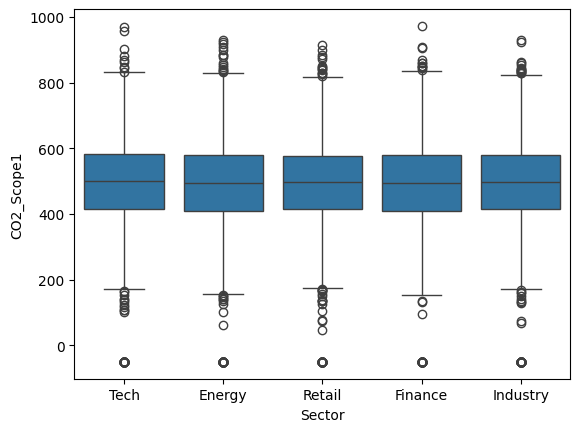

In [28]:
sns.boxplot(df,
            x="Sector",
            y="CO2_Scope1")
plt.show()

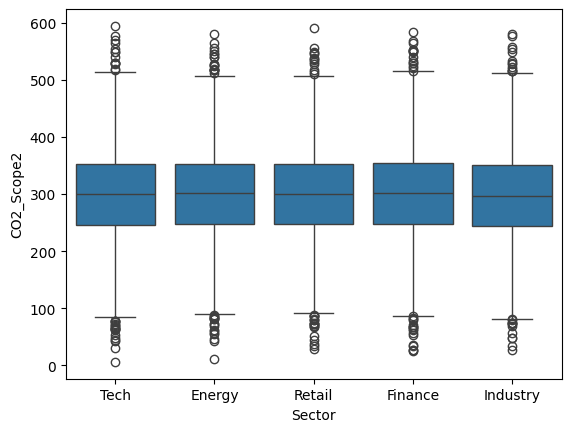

In [29]:
sns.boxplot(df,
            x="Sector",
            y="CO2_Scope2")
plt.show()

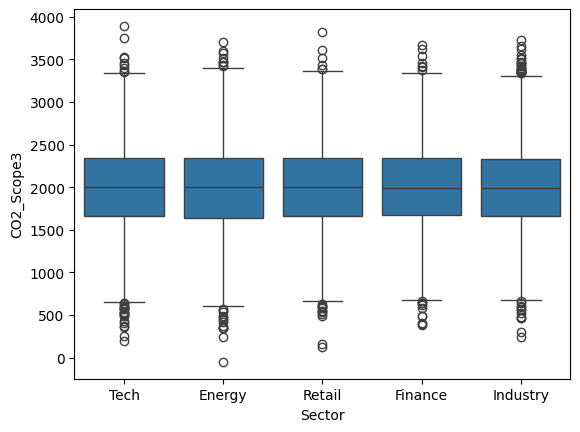

In [30]:
sns.boxplot(df,
            x="Sector",
            y="CO2_Scope3")
plt.show()

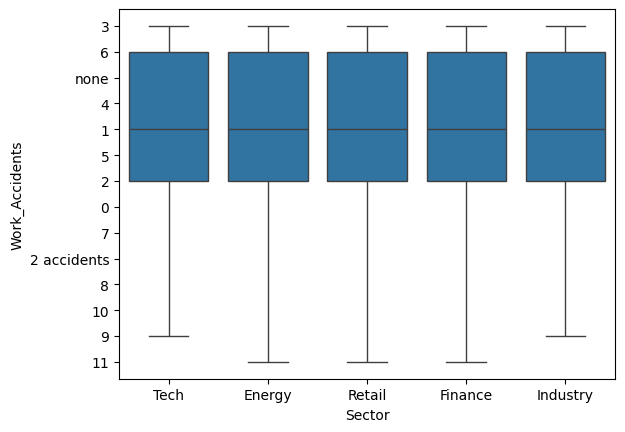

In [31]:
sns.boxplot(df,
            x="Sector",
            y="Work_Accidents")
plt.show()

<Axes: xlabel='Sector', ylabel='Work_Accidents'>

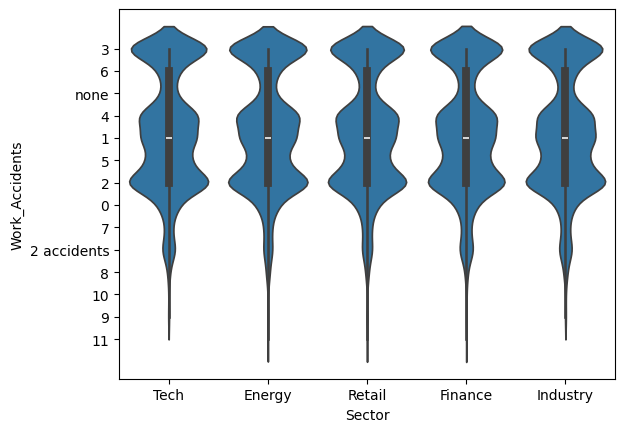

In [35]:
sns.violinplot(df,
               x="Sector",
               y="Work_Accidents")

<Axes: xlabel='Sector', ylabel='CO2_Scope1'>

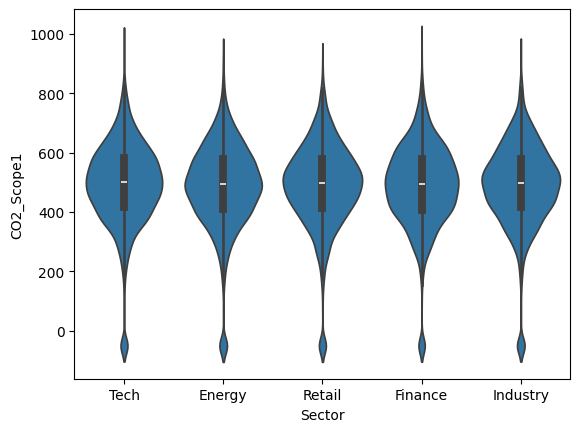

In [36]:
sns.violinplot(df,
               x="Sector",
               y="CO2_Scope1")

- 3.1 Par année

In [32]:
df.groupby("Fiscal_Year")[["CO2_Scope1","CO2_Scope2","CO2_Scope3"]].mean()

,CO2_Scope1,CO2_Scope2,CO2_Scope3
Fiscal_Year,,,
2020,489.906925,299.455059,2000.798600
2021,488.936425,299.742181,2006.331600
2022,489.572150,299.982131,1998.917450
2023,487.895600,298.199447,1988.324225
2024,489.651575,299.667094,1995.510550


# CONCLUSION
- Problèmes de qualité détectés
- Colonnes prioritaires à nettoyer
- Décisions à appliquer dans Dataiku: normalisation formats/ standardisation catégories/ parsing JSON/ flags d'anomalies/ gestion des NaN

## identification des valeurs hors normes

In [33]:
# df["Waste_Issue"] = df["Waste_Recycled_Ratio"].apply(lambda x: x < 0 or x > 1 )
# print(f"il y a",df["Waste_Issue"].mean() * 100,"% de valeurs anormales")